In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_palette("Set2")
sns.set_style("whitegrid")

In [3]:
data_seed_0 = pd.read_json("../outputs/01_grid__epochs_mobilenet/seed_0/run_000/epoch_metrics.json")
data_seed_42 = pd.read_json(
    "../outputs/01_grid__epochs_mobilenet/seed_42/run_000/epoch_metrics.json"
)
data_seed_3407 = pd.read_json(
    "../outputs/01_grid__epochs_mobilenet/seed_3407/run_000/epoch_metrics.json"
)

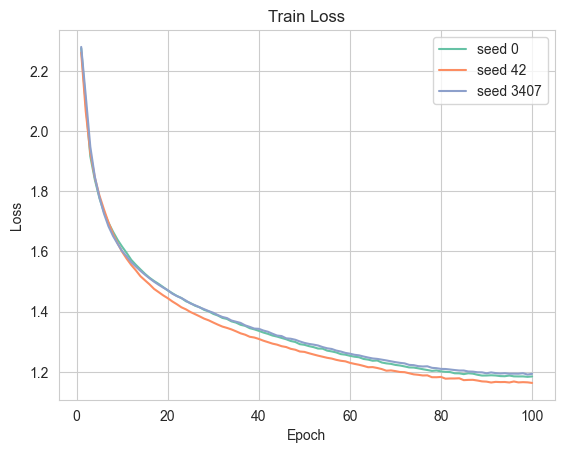

In [4]:
sns.lineplot(data=data_seed_0, x="epoch", y="train_loss", label="seed 0")
sns.lineplot(data=data_seed_42, x="epoch", y="train_loss", label="seed 42")
sns.lineplot(data=data_seed_3407, x="epoch", y="train_loss", label="seed 3407")
plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8))

seed_data = {
    "seed 0": data_seed_0,
    "seed 42": data_seed_42,
    "seed 3407": data_seed_3407,
}

# --- Validation Accuracy (left plot) ---
best_points = []
for label, df in seed_data.items():
    sns.lineplot(data=df, x="epoch", y="val_accuracy", label=label, ax=ax1)
    line_color = ax1.lines[-1].get_color()

    best_idx = df["val_accuracy"].idxmax()
    best_epoch = df.loc[best_idx, "epoch"]
    best_acc = df.loc[best_idx, "val_accuracy"]

    ax1.scatter(best_epoch, best_acc, s=60, zorder=5, color=line_color)
    best_points.append((label, best_epoch, best_acc, line_color))

# Manual label offsets for accuracy (in data coordinates).
manual_x_shift_acc = {
    "seed 0": 0.0,
    "seed 42": 10.0,
    "seed 3407": -10.0,
}
manual_y_shift_acc = {
    "seed 0": -0.03,
    "seed 42": 0.0,
    "seed 3407": 0.0,
}

for label, best_epoch, best_acc, color in best_points:
    x_text = float(best_epoch) + manual_x_shift_acc[label]
    y_text = float(best_acc) + manual_y_shift_acc[label]

    if x_text > best_epoch:
        ha = "left"
    elif x_text < best_epoch:
        ha = "right"
    else:
        ha = "center"
        if not hasattr(fig, "_fontscale_hook_added"):

            def _scale_all_fonts_once(_):
                if getattr(fig, "_fontscale_done", False):
                    return
                for obj in fig.findobj():
                    if hasattr(obj, "get_fontsize") and hasattr(obj, "set_fontsize"):
                        obj.set_fontsize(obj.get_fontsize() * 1.5)
                fig._fontscale_done = True
                fig.canvas.draw_idle()

            fig.canvas.mpl_connect("draw_event", _scale_all_fonts_once)
            fig._fontscale_hook_added = True
    if y_text > best_acc:
        va = "bottom"
    elif y_text < best_acc:
        va = "top"
    else:
        va = "center"

    ax1.annotate(
        f"{label}: e{int(best_epoch)}, {best_acc:.3f}",
        xy=(best_epoch, best_acc),
        xytext=(x_text, y_text),
        textcoords="data",
        ha=ha,
        va=va,
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.2", "fc": "white", "ec": color, "alpha": 0.85},
        arrowprops={"arrowstyle": "-", "lw": 0.8, "color": color},
    )

ax1.set_title("Validation Accuracy")
ax1.set_xlabel("")
ax1.set_ylabel("Accuracy")
ax1.legend()

# --- Validation Loss (right plot) ---
min_points = []
for label, df in seed_data.items():
    sns.lineplot(data=df, x="epoch", y="val_loss", label=label, ax=ax2)
    line_color = ax2.lines[-1].get_color()

    min_idx = df["val_loss"].idxmin()
    min_epoch = df.loc[min_idx, "epoch"]
    min_loss = df.loc[min_idx, "val_loss"]

    ax2.scatter(min_epoch, min_loss, s=60, zorder=5, color=line_color)
    min_points.append((label, min_epoch, min_loss, line_color))

# Manual label offsets for loss (in data coordinates).
manual_x_shift_loss = {
    "seed 0": 0.0,
    "seed 42": -10.0,
    "seed 3407": 10.0,
}
manual_y_shift_loss = {
    "seed 0": 0.06,
    "seed 42": 0.0,
    "seed 3407": 0.0,
}

for label, min_epoch, min_loss, color in min_points:
    x_text = float(min_epoch) + manual_x_shift_loss[label]
    y_text = float(min_loss) + manual_y_shift_loss[label]

    if x_text > min_epoch:
        ha = "left"
    elif x_text < min_epoch:
        ha = "right"
    else:
        ha = "center"

    if y_text > min_loss:
        va = "bottom"
    elif y_text < min_loss:
        va = "top"
    else:
        va = "center"

    ax2.annotate(
        f"{label}: e{int(min_epoch)}, {min_loss:.3f}",
        xy=(min_epoch, min_loss),
        xytext=(x_text, y_text),
        textcoords="data",
        ha=ha,
        va=va,
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.2", "fc": "white", "ec": color, "alpha": 0.85},
        arrowprops={"arrowstyle": "-", "lw": 0.8, "color": color},
    )

ax2.set_title("Validation Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend().set_visible(False)

plt.tight_layout()
plt.savefig("./plots/stage0_grid.png", dpi=500, bbox_inches="tight", pad_inches=0.1)
plt.show()

TypeError: _scale_all_fonts_once() takes 0 positional arguments but 1 was given

Error in callback <function _draw_all_if_interactive at 0x106a72a20> (for post_execute), with arguments args (),kwargs {}:


TypeError: _scale_all_fonts_once() takes 0 positional arguments but 1 was given

TypeError: _scale_all_fonts_once() takes 0 positional arguments but 1 was given

<Figure size 700x800 with 2 Axes>